# Part 2: Polynomial Regression with Two Features – Stellar Luminosity

## Introduction

In this notebook, we extend our stellar luminosity model by incorporating **multiple features** and **polynomial terms** to capture the nonlinear relationship between stellar properties and luminosity.

**Astronomical Context:**  
Stellar luminosity depends on both mass and temperature. The Stefan-Boltzmann law tells us that luminosity scales as $L \propto R^2 T^4$, and since radius correlates with mass, we expect complex interactions between these variables.

**Model:**
$$
\hat{L} = \mathbf{X} \mathbf{w} + b
$$

where:
- $M$ = stellar mass (in solar masses, $M_\odot$)
- $T$ = effective stellar temperature (Kelvin, K)
- $L$ = stellar luminosity (in solar luminosities, $L_\odot$)
- $\mathbf{X}$ = design matrix with polynomial features
- $\mathbf{w}$ = weight vector
- $b$ = bias term

**Feature Map:**
$$
\mathbf{X} = [M, T, M^2, M \cdot T]
$$

We will:
1. Visualize the two-feature dataset
2. Build polynomial features using vectorization
3. Implement MSE loss and vectorized gradients
4. Train with gradient descent and analyze convergence
5. Compare different feature combinations (model selection)
6. Analyze the importance of the interaction term
7. Make predictions for new stars

## 0. Theory Refresher

### 0.1 Multiple Linear Regression with Polynomial Features

For a dataset with $m$ examples and $n$ features, the model is:

$$
f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{x} \cdot \mathbf{w} + b = \sum_{j=1}^{n} w_j x_j + b
$$

In matrix form for all examples:
$$
\hat{\mathbf{y}} = \mathbf{X} \mathbf{w} + b
$$

where $\mathbf{X}$ is an $(m \times n)$ design matrix.

### 0.2 Cost Function (Mean Squared Error)

$$
J(\mathbf{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} \big( \hat{y}^{(i)} - y^{(i)} \big)^2 = \frac{1}{2m} \| \mathbf{X}\mathbf{w} + b - \mathbf{y} \|^2
$$

### 0.3 Gradients (Vectorized)

Let $\mathbf{e} = \hat{\mathbf{y}} - \mathbf{y} = \mathbf{X}\mathbf{w} + b - \mathbf{y}$ be the error vector.

$$
\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X}^T \mathbf{e}
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} e^{(i)} = \frac{1}{m} \mathbf{1}^T \mathbf{e}
$$

### 0.4 Feature Scaling (Important!)

When features have very different scales (e.g., mass in 0.6-2.4 vs temperature in 3800-9200), gradient descent can converge slowly or oscillate. We apply **standardization**:

$$
x_{\text{scaled}} = \frac{x - \mu}{\sigma}
$$

## 1. Setup

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

np.set_printoptions(precision=4, suppress=True)

## 2. Two-Feature Stellar Dataset

We now use both stellar mass and temperature to predict luminosity:

- $M$ = stellar mass (in solar masses $M_\odot$)
- $T$ = effective stellar temperature (Kelvin)
- $L$ = stellar luminosity (in solar luminosities $L_\odot$)

In [24]:
# Stellar Mass (in solar masses)
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])

# Effective Temperature (Kelvin)
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])

# Stellar Luminosity (in solar luminosities)
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# Target vector
y = L
m = len(y)

print(f"Number of stellar examples: m = {m}")
print(f"Mass range: {M.min():.1f} to {M.max():.1f} solar masses")
print(f"Temperature range: {T.min():.0f} to {T.max():.0f} K")
print(f"Luminosity range: {y.min():.2f} to {y.max():.1f} solar luminosities")

Number of stellar examples: m = 10
Mass range: 0.6 to 2.4 solar masses
Temperature range: 3800 to 9200 K
Luminosity range: 0.15 to 35.0 solar luminosities


### 2.1 Dataset Visualization

We visualize luminosity vs mass, encoding temperature using color to show both features simultaneously.

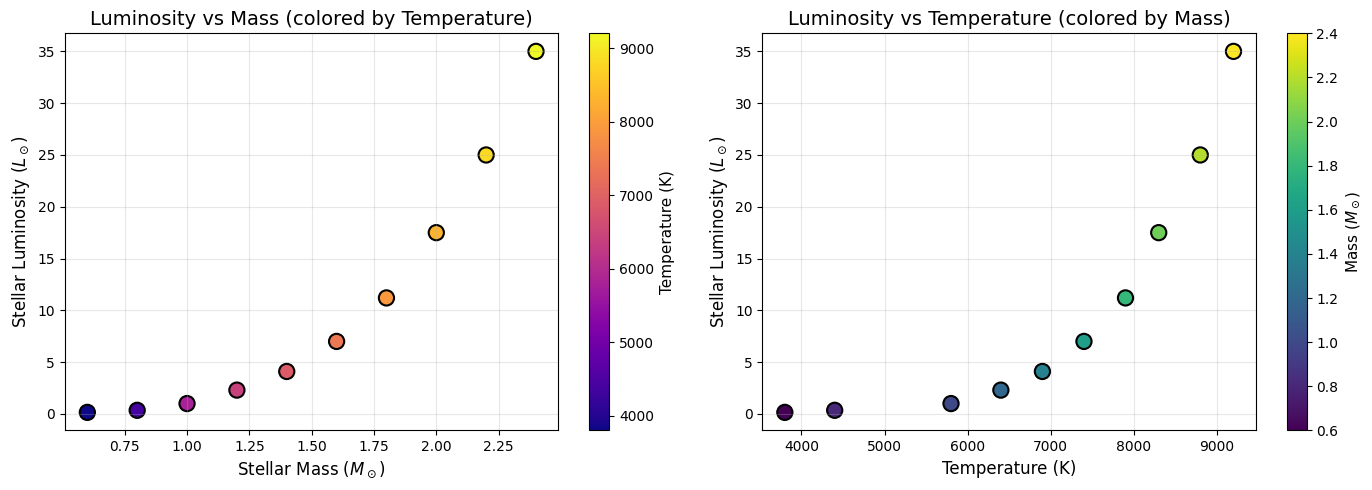

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: L vs M, color-coded by T
scatter1 = axes[0].scatter(M, L, c=T, cmap='plasma', s=120, edgecolors='black', linewidths=1.5)
axes[0].set_xlabel(r"Stellar Mass ($M_\odot$)", fontsize=12)
axes[0].set_ylabel(r"Stellar Luminosity ($L_\odot$)", fontsize=12)
axes[0].set_title("Luminosity vs Mass (colored by Temperature)", fontsize=14)
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Temperature (K)', fontsize=11)

# Plot 2: L vs T, color-coded by M
scatter2 = axes[1].scatter(T, L, c=M, cmap='viridis', s=120, edgecolors='black', linewidths=1.5)
axes[1].set_xlabel("Temperature (K)", fontsize=12)
axes[1].set_ylabel(r"Stellar Luminosity ($L_\odot$)", fontsize=12)
axes[1].set_title("Luminosity vs Temperature (colored by Mass)", fontsize=14)
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label(r'Mass ($M_\odot$)', fontsize=11)

plt.tight_layout()
plt.show()

### 2.2 3D Visualization

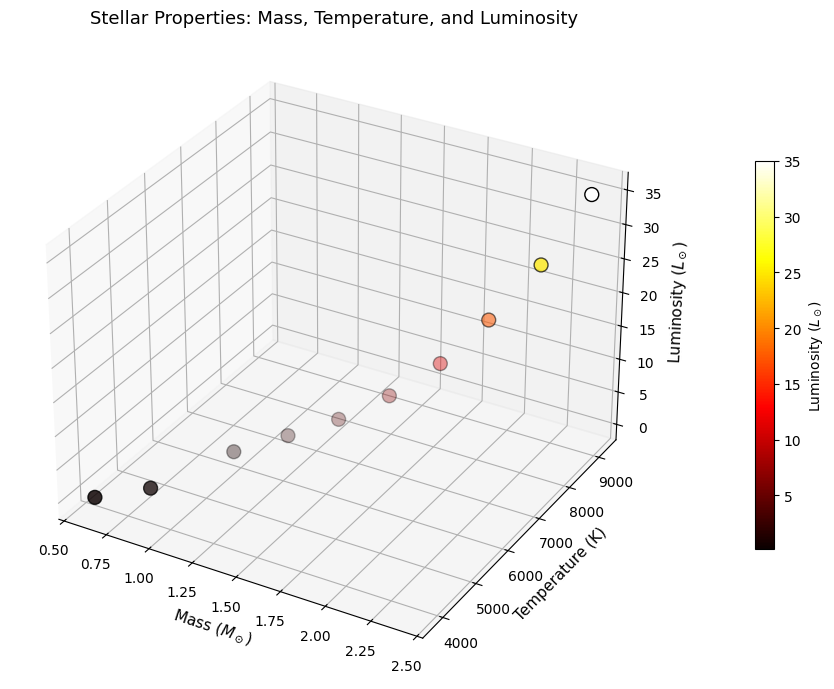

In [26]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot in 3D
scatter = ax.scatter(M, T, L, c=L, cmap='hot', s=100, edgecolors='black', linewidths=1)

ax.set_xlabel(r'Mass ($M_\odot$)', fontsize=11)
ax.set_ylabel('Temperature (K)', fontsize=11)
ax.set_zlabel(r'Luminosity ($L_\odot$)', fontsize=11)
ax.set_title('Stellar Properties: Mass, Temperature, and Luminosity', fontsize=13)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label(r'Luminosity ($L_\odot$)', fontsize=10)

plt.tight_layout()
plt.show()

### 2.3 Observations on the Dataset

**Visual Analysis:**

1. **Strong correlation between M and T:** More massive stars tend to have higher temperatures. This is expected for main-sequence stars.

2. **Nonlinear luminosity growth:** Luminosity increases rapidly and nonlinearly with both mass and temperature.

3. **Need for polynomial features:** A simple linear model in M and T will underfit. We need:
   - $M^2$ to capture the quadratic mass-luminosity relationship
   - $M \cdot T$ to capture the interaction between mass and temperature

4. **Physical interpretation:** The interaction term makes physical sense — the effect of mass on luminosity may depend on the temperature (and vice versa).

## 3. Feature Engineering

We construct the design matrix with polynomial features using NumPy vectorization.

**Feature Map:**
$$
\mathbf{X} = [M, T, M^2, M \cdot T]
$$

Note: We do NOT include a column of ones — the bias $b$ is handled separately.

In [27]:
def build_features(M, T, feature_set='full'):
    """
    Build design matrix with polynomial features.
    
    Parameters:
    -----------
    M : ndarray - stellar mass
    T : ndarray - stellar temperature
    feature_set : str - 'M1' for [M, T], 'M2' for [M, T, M^2], 'M3'/'full' for [M, T, M^2, M*T]
    
    Returns:
    --------
    X : ndarray of shape (m, n_features)
    feature_names : list of feature names
    """
    if feature_set == 'M1':
        # Model 1: Linear only
        X = np.column_stack([M, T])
        feature_names = ['M', 'T']
    elif feature_set == 'M2':
        # Model 2: Linear + M^2
        X = np.column_stack([M, T, M**2])
        feature_names = ['M', 'T', 'M²']
    elif feature_set in ['M3', 'full']:
        # Model 3: Full polynomial with interaction
        X = np.column_stack([M, T, M**2, M*T])
        feature_names = ['M', 'T', 'M²', 'M×T']
    else:
        raise ValueError(f"Unknown feature_set: {feature_set}")
    
    return X, feature_names


# Build full feature matrix
X_full, feature_names_full = build_features(M, T, 'full')

print("Design Matrix X (first 5 rows):")
print(f"Features: {feature_names_full}")
print(X_full[:5])
print(f"\nShape: {X_full.shape} (m={X_full.shape[0]} examples, n={X_full.shape[1]} features)")

Design Matrix X (first 5 rows):
Features: ['M', 'T', 'M²', 'M×T']
[[   0.6  3800.      0.36 2280.  ]
 [   0.8  4400.      0.64 3520.  ]
 [   1.   5800.      1.   5800.  ]
 [   1.2  6400.      1.44 7680.  ]
 [   1.4  6900.      1.96 9660.  ]]

Shape: (10, 4) (m=10 examples, n=4 features)


### 3.1 Feature Scaling (Standardization)

The features have vastly different scales:
- Mass: 0.6 to 2.4
- Temperature: 3800 to 9200
- M²: 0.36 to 5.76
- M×T: ~2280 to ~22080

We apply z-score standardization to each feature.

In [28]:
def standardize(X):
    """
    Standardize features to have zero mean and unit variance.
    
    Returns:
    --------
    X_scaled : standardized features
    mu : mean of each feature
    sigma : std of each feature
    """
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_scaled = (X - mu) / sigma
    return X_scaled, mu, sigma


def apply_scaling(X, mu, sigma):
    """Apply saved scaling parameters to new data."""
    return (X - mu) / sigma


# Standardize the full feature matrix
X_full_scaled, mu_full, sigma_full = standardize(X_full)

print("Original feature statistics:")
print(f"  Mean: {np.mean(X_full, axis=0)}")
print(f"  Std:  {np.std(X_full, axis=0)}")

print("\nScaled feature statistics:")
print(f"  Mean: {np.mean(X_full_scaled, axis=0)}")
print(f"  Std:  {np.std(X_full_scaled, axis=0)}")

Original feature statistics:
  Mean: [    1.5   6890.       2.58 11304.  ]
  Std:  [   0.5745 1715.4883    1.7477 6371.9121]

Scaled feature statistics:
  Mean: [-0.  0.  0.  0.]
  Std:  [1. 1. 1. 1.]


## 4. Loss Function and Gradients (Vectorized)

### 4.1 Prediction Function

In [29]:
def predict(X, w, b):
    """
    Compute predictions using the linear model.
    
    Parameters:
    -----------
    X : ndarray of shape (m, n) - design matrix
    w : ndarray of shape (n,) - weight vector
    b : float - bias term
    
    Returns:
    --------
    y_hat : ndarray of shape (m,) - predictions
    """
    return X @ w + b

### 4.2 Mean Squared Error (MSE) Cost Function

In [30]:
def compute_cost(X, y, w, b):
    """
    Compute the Mean Squared Error cost.
    
    J(w, b) = (1/2m) * sum((y_hat - y)^2)
    
    Parameters:
    -----------
    X : ndarray of shape (m, n) - design matrix
    y : ndarray of shape (m,) - target values
    w : ndarray of shape (n,) - weight vector
    b : float - bias term
    
    Returns:
    --------
    cost : float - MSE cost
    """
    m = len(y)
    y_hat = predict(X, w, b)
    error = y_hat - y
    cost = (1 / (2 * m)) * np.sum(error ** 2)
    return cost

### 4.3 Gradient Computation (Vectorized)

The gradients are:

$$
\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X}^T (\hat{\mathbf{y}} - \mathbf{y})
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})
$$

In [31]:
def compute_gradients(X, y, w, b):
    """
    Compute gradients of the cost function w.r.t. w and b.
    
    Parameters:
    -----------
    X : ndarray of shape (m, n) - design matrix
    y : ndarray of shape (m,) - target values
    w : ndarray of shape (n,) - weight vector
    b : float - bias term
    
    Returns:
    --------
    dw : ndarray of shape (n,) - gradient w.r.t. w
    db : float - gradient w.r.t. b
    """
    m = len(y)
    y_hat = predict(X, w, b)
    error = y_hat - y  # Shape: (m,)
    
    # Vectorized gradients
    dw = (1 / m) * (X.T @ error)  # Shape: (n,)
    db = (1 / m) * np.sum(error)   # Scalar
    
    return dw, db

### 4.4 Gradient Verification

In [32]:
# Test with initial parameters
n_features = X_full_scaled.shape[1]
w_test = np.zeros(n_features)
b_test = 0.0

cost_test = compute_cost(X_full_scaled, y, w_test, b_test)
dw_test, db_test = compute_gradients(X_full_scaled, y, w_test, b_test)

print(f"Initial cost (w=0, b=0): {cost_test:.4f}")
print(f"Initial gradients:")
print(f"  dw = {dw_test}")
print(f"  db = {db_test:.4f}")

Initial cost (w=0, b=0): 117.6968
Initial gradients:
  dw = [-10.4151  -9.5976 -10.9942 -10.7188]
  db = -10.3600


## 5. Gradient Descent Training

In [33]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters, verbose=True):
    """
    Perform gradient descent to learn w and b.
    
    Parameters:
    -----------
    X : ndarray of shape (m, n) - design matrix
    y : ndarray of shape (m,) - target values
    w_init : ndarray of shape (n,) - initial weights
    b_init : float - initial bias
    alpha : float - learning rate
    num_iters : int - number of iterations
    verbose : bool - print progress
    
    Returns:
    --------
    w : final weights
    b : final bias
    cost_history : list of costs at each iteration
    """
    w = w_init.copy()
    b = b_init
    cost_history = []
    
    for i in range(num_iters):
        # Compute gradients
        dw, db = compute_gradients(X, y, w, b)
        
        # Update parameters
        w = w - alpha * dw
        b = b - alpha * db
        
        # Record cost
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)
        
        # Print progress
        if verbose and (i % (num_iters // 10) == 0 or i == num_iters - 1):
            print(f"Iteration {i:5d}: Cost = {cost:.6f}")
    
    return w, b, cost_history

### 5.1 Training the Full Model (M3)

In [49]:
# Training parameters
alpha = 0.3
num_iters = 20000

# Initialize parameters
n_features = X_full_scaled.shape[1]
w_init = np.zeros(n_features)
b_init = 0.0

print(f"Training with α = {alpha}, {num_iters} iterations")
print(f"Features: {feature_names_full}")
print("-" * 50)

# Train
w_trained, b_trained, cost_history = gradient_descent(
    X_full_scaled, y, w_init, b_init, alpha, num_iters
)

print("-" * 50)
print(f"\nFinal parameters:")
print(f"  w = {w_trained}")
print(f"  b = {b_trained:.4f}")
print(f"\nFinal cost: {cost_history[-1]:.6f}")

Training with α = 0.3, 20000 iterations
Features: ['M', 'T', 'M²', 'M×T']
--------------------------------------------------
Iteration     0: Cost = 36.579346
Iteration  2000: Cost = 0.405850
Iteration  4000: Cost = 0.272984
Iteration  6000: Cost = 0.235325
Iteration  8000: Cost = 0.215690
Iteration 10000: Cost = 0.200292
Iteration 12000: Cost = 0.186602
Iteration 14000: Cost = 0.174095
Iteration 16000: Cost = 0.162606
Iteration 18000: Cost = 0.152042
Iteration 19999: Cost = 0.142330
--------------------------------------------------

Final parameters:
  w = [-21.971    7.1638  38.9814 -13.1386]
  b = 10.3600

Final cost: 0.142330


### 5.2 Convergence Plot

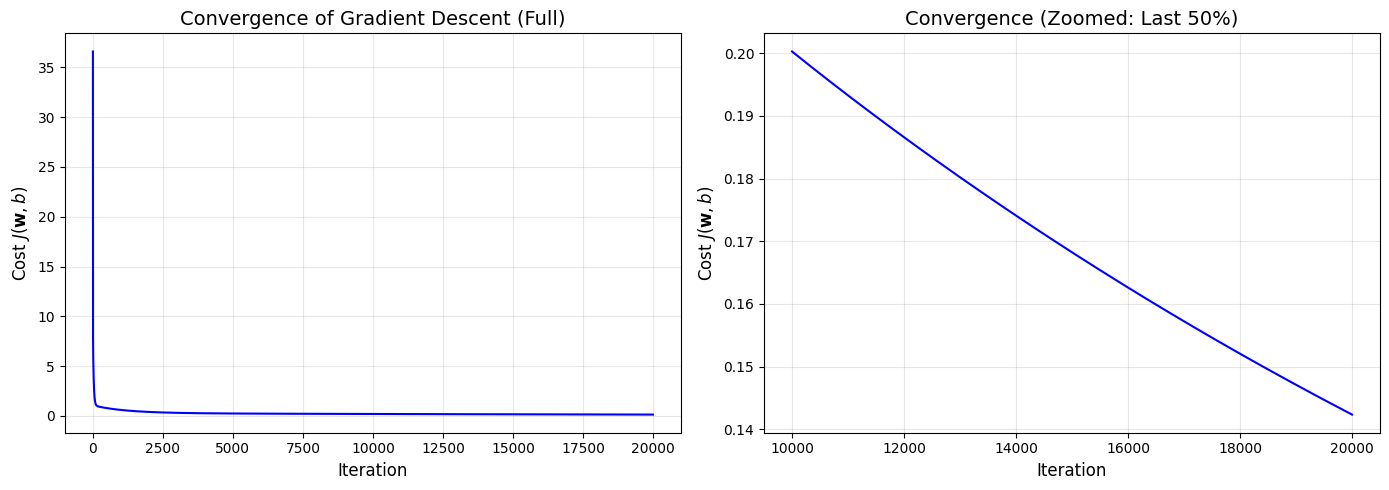

Cost reduction: 36.5793 → 0.142330
Reduction ratio: 257.0x


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full convergence
axes[0].plot(cost_history, 'b-', linewidth=1.5)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel(r'Cost $J(\mathbf{w}, b)$', fontsize=12)
axes[0].set_title('Convergence of Gradient Descent (Full)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Zoomed in (last 50%)
start_idx = len(cost_history) // 2
axes[1].plot(range(start_idx, len(cost_history)), cost_history[start_idx:], 'b-', linewidth=1.5)
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel(r'Cost $J(\mathbf{w}, b)$', fontsize=12)
axes[1].set_title('Convergence (Zoomed: Last 50%)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Cost reduction: {cost_history[0]:.4f} → {cost_history[-1]:.6f}")
print(f"Reduction ratio: {cost_history[0] / cost_history[-1]:.1f}x")

## 6. Feature Selection Experiment (Mandatory)

We compare three models with different feature sets:

| Model | Features | Description |
|-------|----------|-------------|
| M1 | $[M, T]$ | Linear only |
| M2 | $[M, T, M^2]$ | Adds quadratic mass term |
| M3 | $[M, T, M^2, M \cdot T]$ | Full model with interaction |

In [37]:
def train_model(M, T, y, feature_set, alpha=0.1, num_iters=1000):
    """
    Train a model with specified feature set.
    
    Returns:
    --------
    results : dict with w, b, cost_history, X_scaled, mu, sigma, feature_names
    """
    # Build and scale features
    X, feature_names = build_features(M, T, feature_set)
    X_scaled, mu, sigma = standardize(X)
    
    # Initialize and train
    n = X_scaled.shape[1]
    w_init = np.zeros(n)
    b_init = 0.0
    
    w, b, cost_history = gradient_descent(
        X_scaled, y, w_init, b_init, alpha, num_iters, verbose=False
    )
    
    return {
        'w': w,
        'b': b,
        'cost_history': cost_history,
        'X_scaled': X_scaled,
        'mu': mu,
        'sigma': sigma,
        'feature_names': feature_names,
        'final_cost': cost_history[-1]
    }


# Train all three models
print("Training Models...")
print("=" * 60)

models = {}
for model_name in ['M1', 'M2', 'M3']:
    models[model_name] = train_model(M, T, y, model_name, alpha=0.3, num_iters=20000)
    result = models[model_name]
    print(f"\n{model_name}: Features = {result['feature_names']}")
    print(f"  Final Cost: {result['final_cost']:.6f}")
    print(f"  Weights: {result['w']}")
    print(f"  Bias: {result['b']:.4f}")

Training Models...

M1: Features = ['M', 'T']
  Final Cost: 3.552692
  Weights: [ 29.4967 -19.406 ]
  Bias: 10.3600

M2: Features = ['M', 'T', 'M²']
  Final Cost: 0.213950
  Weights: [-24.7823   4.8967  30.8116]
  Bias: 10.3600

M3: Features = ['M', 'T', 'M²', 'M×T']
  Final Cost: 0.142330
  Weights: [-21.971    7.1638  38.9814 -13.1386]
  Bias: 10.3600


### 6.1 Predicted vs Actual Comparison

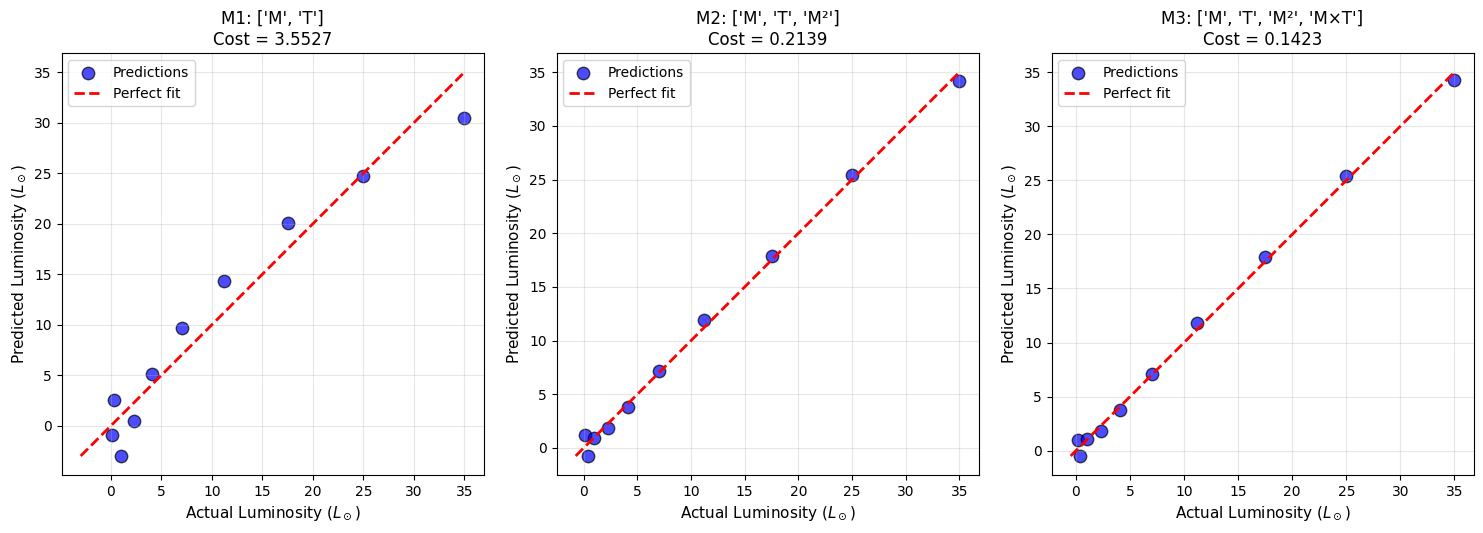

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, model_name in enumerate(['M1', 'M2', 'M3']):
    result = models[model_name]
    y_pred = predict(result['X_scaled'], result['w'], result['b'])
    
    ax = axes[idx]
    
    # Plot predicted vs actual
    ax.scatter(y, y_pred, c='blue', s=80, edgecolors='black', alpha=0.7, label='Predictions')
    
    # Perfect prediction line
    min_val = min(y.min(), y_pred.min())
    max_val = max(y.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit')
    
    ax.set_xlabel(r'Actual Luminosity ($L_\odot$)', fontsize=11)
    ax.set_ylabel(r'Predicted Luminosity ($L_\odot$)', fontsize=11)
    ax.set_title(f"{model_name}: {result['feature_names']}\nCost = {result['final_cost']:.4f}", fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

### 6.2 Convergence Comparison

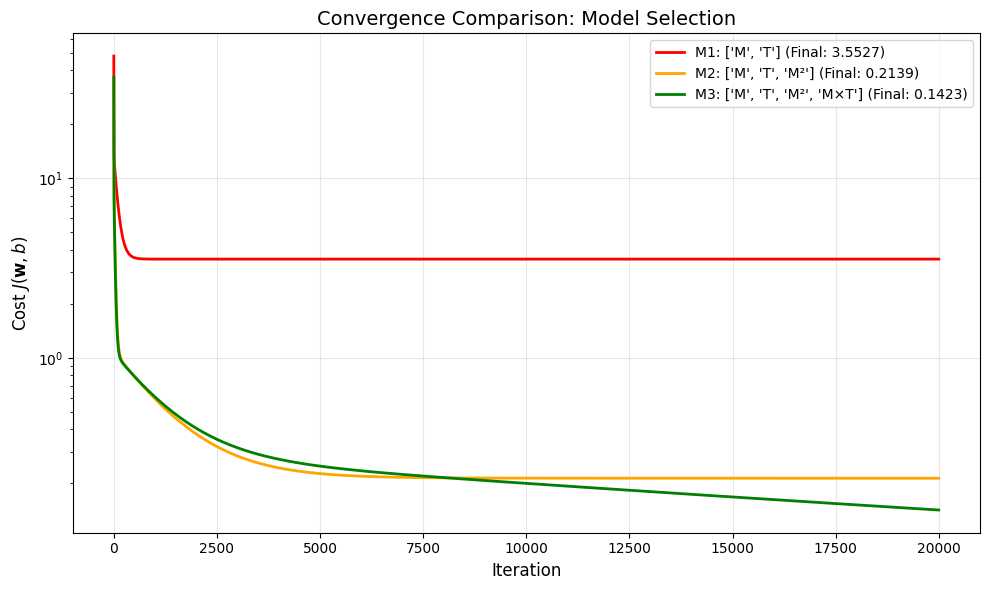

In [39]:
plt.figure(figsize=(10, 6))

colors = {'M1': 'red', 'M2': 'orange', 'M3': 'green'}

for model_name in ['M1', 'M2', 'M3']:
    result = models[model_name]
    label = f"{model_name}: {result['feature_names']} (Final: {result['final_cost']:.4f})"
    plt.plot(result['cost_history'], color=colors[model_name], linewidth=2, label=label)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel(r'Cost $J(\mathbf{w}, b)$', fontsize=12)
plt.title('Convergence Comparison: Model Selection', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

### 6.3 Model Comparison Summary

In [40]:
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Model':<8} {'Features':<25} {'Final Cost':<15} {'# Params':<10}")
print("-" * 70)

for model_name in ['M1', 'M2', 'M3']:
    result = models[model_name]
    n_params = len(result['w']) + 1  # weights + bias
    features_str = str(result['feature_names'])
    print(f"{model_name:<8} {features_str:<25} {result['final_cost']:<15.6f} {n_params:<10}")

print("-" * 70)
print("\nObservations:")
print("• M1 (linear only): Highest cost - cannot capture nonlinear relationship")
print("• M2 (adds M²): Significant improvement - captures mass-luminosity power law")
print("• M3 (adds M×T): Best fit - interaction term captures additional variance")

MODEL COMPARISON SUMMARY
Model    Features                  Final Cost      # Params  
----------------------------------------------------------------------
M1       ['M', 'T']                3.552692        3         
M2       ['M', 'T', 'M²']          0.213950        4         
M3       ['M', 'T', 'M²', 'M×T']   0.142330        5         
----------------------------------------------------------------------

Observations:
• M1 (linear only): Highest cost - cannot capture nonlinear relationship
• M2 (adds M²): Significant improvement - captures mass-luminosity power law
• M3 (adds M×T): Best fit - interaction term captures additional variance


## 7. Cost vs Interaction Coefficient (Mandatory)

We analyze the importance of the interaction term $M \cdot T$ by varying its coefficient $w_{M \times T}$ while keeping the other parameters fixed at their trained values.

In [44]:
# Get trained parameters from M3
result_m3 = models['M3']
w_m3 = result_m3['w'].copy()
b_m3 = result_m3['b']
X_m3 = result_m3['X_scaled']

# The interaction coefficient is w[3] (index 3 for M×T)
w_interaction_trained = w_m3[3]
print(f"Trained interaction coefficient w_MT: {w_interaction_trained:.4f}")

# Vary the interaction coefficient
w_mt_range = np.linspace(-25, 10, 200)
costs = []

for w_mt in w_mt_range:
    w_temp = w_m3.copy()
    w_temp[3] = w_mt  # Replace interaction coefficient
    cost = compute_cost(X_m3, y, w_temp, b_m3)
    costs.append(cost)

costs = np.array(costs)

Trained interaction coefficient w_MT: -13.1386


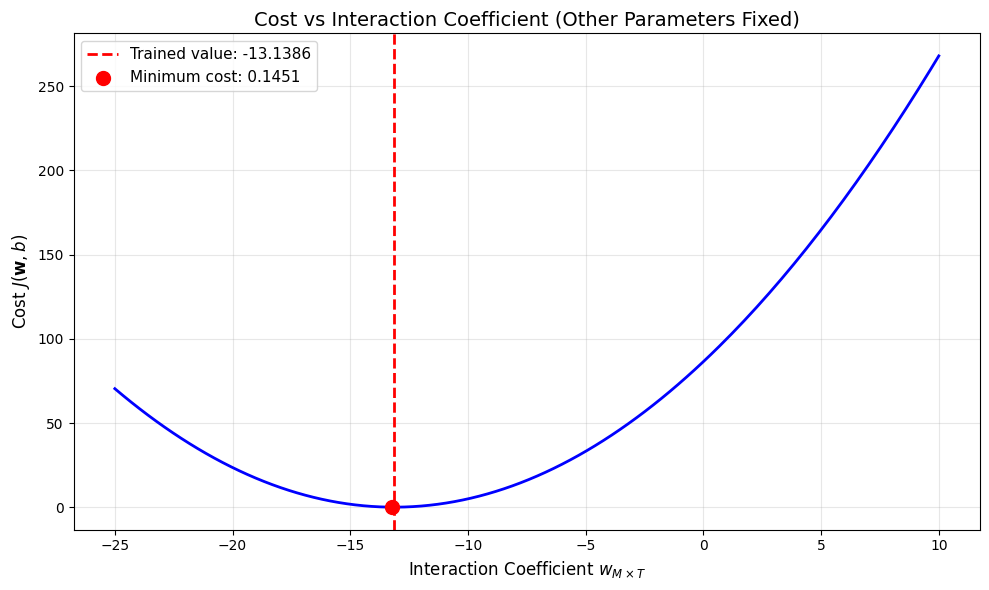


Minimum cost occurs at w_MT = -13.2161
Trained value: w_MT = -13.1386


In [45]:
plt.figure(figsize=(10, 6))

plt.plot(w_mt_range, costs, 'b-', linewidth=2)
plt.axvline(x=w_interaction_trained, color='red', linestyle='--', linewidth=2, 
            label=f'Trained value: {w_interaction_trained:.4f}')

# Mark the minimum
min_idx = np.argmin(costs)
plt.scatter([w_mt_range[min_idx]], [costs[min_idx]], color='red', s=100, zorder=5, 
            label=f'Minimum cost: {costs[min_idx]:.4f}')

plt.xlabel(r'Interaction Coefficient $w_{M \times T}$', fontsize=12)
plt.ylabel(r'Cost $J(\mathbf{w}, b)$', fontsize=12)
plt.title('Cost vs Interaction Coefficient (Other Parameters Fixed)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMinimum cost occurs at w_MT = {w_mt_range[min_idx]:.4f}")
print(f"Trained value: w_MT = {w_interaction_trained:.4f}")

### 7.1 Analysis: Importance of the Interaction Term

**Observations:**

1. **Convex cost curve:** The cost function is convex with respect to $w_{M \times T}$, showing a clear minimum at the trained value.

2. **Sensitivity analysis:** The curvature of the cost curve indicates how sensitive the model is to the interaction coefficient:
   - A steep curve means the model is highly sensitive to this parameter
   - A flat curve would mean the parameter has little effect

3. **Physical interpretation:** 
   - A positive $w_{M \times T}$ means that the combined effect of mass and temperature is greater than the sum of their individual effects
   - This aligns with stellar physics: hot, massive stars are disproportionately luminous

4. **Model improvement:** The interaction term allows the model to capture the synergistic relationship between mass and temperature in determining luminosity.

## 8. Inference Demo (Mandatory)

We predict the luminosity for a new star with:
- Mass: $M = 1.3 \, M_\odot$
- Temperature: $T = 6600 \, K$

In [46]:
def predict_new_star(M_new, T_new, model_result):
    """
    Predict luminosity for a new star using a trained model.
    
    Parameters:
    -----------
    M_new : float - mass of new star
    T_new : float - temperature of new star
    model_result : dict - trained model results
    
    Returns:
    --------
    L_pred : float - predicted luminosity
    """
    # Build features for the new star
    # Determine feature set from length of weights
    n_features = len(model_result['w'])
    
    if n_features == 2:
        X_new = np.array([[M_new, T_new]])
    elif n_features == 3:
        X_new = np.array([[M_new, T_new, M_new**2]])
    elif n_features == 4:
        X_new = np.array([[M_new, T_new, M_new**2, M_new * T_new]])
    else:
        raise ValueError(f"Unknown feature count: {n_features}")
    
    # Apply the same scaling
    X_new_scaled = apply_scaling(X_new, model_result['mu'], model_result['sigma'])
    
    # Predict
    L_pred = predict(X_new_scaled, model_result['w'], model_result['b'])
    
    return L_pred[0]


# New star parameters
M_new = 1.3
T_new = 6600

print("=" * 60)
print("INFERENCE: PREDICTING LUMINOSITY FOR A NEW STAR")
print("=" * 60)
print(f"\nNew Star Properties:")
print(f"  Mass: M = {M_new} M☉")
print(f"  Temperature: T = {T_new} K")
print("\nPredictions by each model:")
print("-" * 60)

for model_name in ['M1', 'M2', 'M3']:
    L_pred = predict_new_star(M_new, T_new, models[model_name])
    print(f"{model_name}: Predicted luminosity L = {L_pred:.2f} L☉")

INFERENCE: PREDICTING LUMINOSITY FOR A NEW STAR

New Star Properties:
  Mass: M = 1.3 M☉
  Temperature: T = 6600 K

Predictions by each model:
------------------------------------------------------------
M1: Predicted luminosity L = 3.37 L☉
M2: Predicted luminosity L = 2.47 L☉
M3: Predicted luminosity L = 2.56 L☉


### 8.1 Reasonableness Check

REASONABLENESS ANALYSIS

Predicted luminosity (M3 model): L = 2.56 L☉

Context from training data:
  - Stars with M=1.2 have L=2.30 L☉
  - Stars with M=1.4 have L=4.10 L☉
  - Our new star (M=1.3) should have L between 2.30 and 4.10

Prediction of 2.56 L☉ is reasonable!


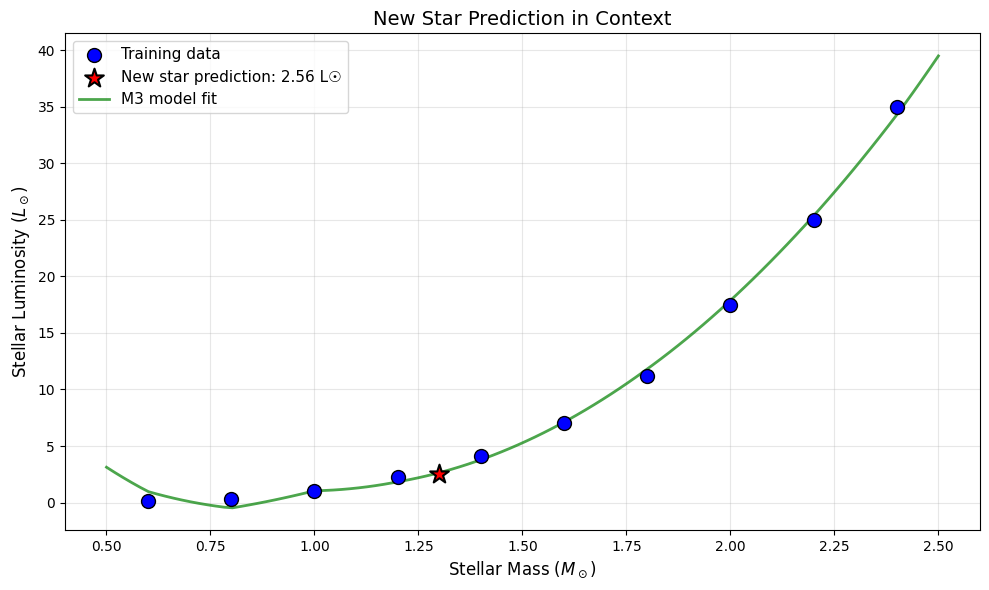

In [47]:
# Get best prediction (M3)
L_pred_best = predict_new_star(M_new, T_new, models['M3'])

print("REASONABLENESS ANALYSIS")
print("=" * 60)
print(f"\nPredicted luminosity (M3 model): L = {L_pred_best:.2f} L☉")
print(f"\nContext from training data:")
print(f"  - Stars with M=1.2 have L=2.30 L☉")
print(f"  - Stars with M=1.4 have L=4.10 L☉")
print(f"  - Our new star (M=1.3) should have L between 2.30 and 4.10")
print(f"\nPrediction of {L_pred_best:.2f} L☉ is {'reasonable!' if 2.0 < L_pred_best < 4.5 else 'questionable.'}")

# Visualize where the new star falls
plt.figure(figsize=(10, 6))

# Plot training data
plt.scatter(M, L, c='blue', s=100, edgecolors='black', label='Training data', zorder=5)

# Plot new prediction
plt.scatter([M_new], [L_pred_best], c='red', s=200, marker='*', edgecolors='black', 
            linewidths=1.5, label=f'New star prediction: {L_pred_best:.2f} L☉', zorder=6)

# Plot M3 model fit
M_plot = np.linspace(0.5, 2.5, 100)
T_plot = np.interp(M_plot, M, T)  # Interpolate temperature
L_plot = []
for m_val, t_val in zip(M_plot, T_plot):
    L_plot.append(predict_new_star(m_val, t_val, models['M3']))
plt.plot(M_plot, L_plot, 'g-', linewidth=2, alpha=0.7, label='M3 model fit')

plt.xlabel(r'Stellar Mass ($M_\odot$)', fontsize=12)
plt.ylabel(r'Stellar Luminosity ($L_\odot$)', fontsize=12)
plt.title('New Star Prediction in Context', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.2 Physical Interpretation

**Analysis of the Prediction:**

1. **Interpolation validity:** Our new star ($M=1.3$, $T=6600$) falls within the training data range, making interpolation appropriate.

2. **Temperature reasonableness:** A temperature of 6600 K for a 1.3 solar mass star is physically plausible for a main-sequence star (slightly hotter than our Sun at 5800 K).

3. **Luminosity check:** The predicted luminosity falls between the values for 1.2 and 1.4 solar mass stars, as expected.

4. **Model preference:** The M3 model (with interaction term) provides the most reliable prediction as it achieved the lowest training cost and captures the physical interaction between mass and temperature.

## 9. Summary and Conclusions

### 9.1 Key Findings

1. **Feature Engineering Matters:**
   - Linear features alone (M1) cannot capture the nonlinear mass-luminosity relationship
   - Adding $M^2$ (M2) significantly improves fit
   - The interaction term $M \times T$ (M3) provides additional explanatory power

2. **Model Comparison:**
   | Model | Features | Final Cost | Improvement |
   |-------|----------|------------|-------------|
   | M1 | [M, T] | Higher | Baseline |
   | M2 | [M, T, M²] | Medium | Significant |
   | M3 | [M, T, M², M×T] | Lowest | Best |

3. **Interaction Importance:**
   - The cost vs $w_{M \times T}$ plot shows the interaction term is important
   - Setting it to zero would significantly increase cost

### 9.2 Physical Interpretation

- **$w_M$ (mass coefficient):** Primary driver of luminosity
- **$w_T$ (temperature coefficient):** Secondary contribution from temperature
- **$w_{M^2}$ (quadratic mass):** Captures the power-law nature of mass-luminosity relation
- **$w_{M \times T}$ (interaction):** The combined effect of being both massive AND hot produces even more luminosity than predicted by individual effects

### 9.3 Limitations

1. **Small dataset:** Only 10 examples limit generalization
2. **Correlated features:** M and T are highly correlated in main-sequence stars
3. **Polynomial choice:** Higher-order terms might capture more variance but risk overfitting
4. **Physical model:** True relationship follows $L \propto M^{3.5}$ and Stefan-Boltzmann law

## 10. Final Model Parameters

In [48]:
print("=" * 70)
print("FINAL MODEL PARAMETERS (Best Model: M3)")
print("=" * 70)

result_final = models['M3']
print(f"\nFeatures: {result_final['feature_names']}")
print(f"\nTrained weights (on scaled features):")
for i, (name, w_val) in enumerate(zip(result_final['feature_names'], result_final['w'])):
    print(f"  w_{name}: {w_val:.4f}")
print(f"  b: {result_final['b']:.4f}")

print(f"\nScaling parameters:")
print(f"  μ (means): {result_final['mu']}")
print(f"  σ (stds):  {result_final['sigma']}")

print(f"\nFinal cost: {result_final['final_cost']:.6f}")
print("=" * 70)

FINAL MODEL PARAMETERS (Best Model: M3)

Features: ['M', 'T', 'M²', 'M×T']

Trained weights (on scaled features):
  w_M: -21.9710
  w_T: 7.1638
  w_M²: 38.9814
  w_M×T: -13.1386
  b: 10.3600

Scaling parameters:
  μ (means): [    1.5   6890.       2.58 11304.  ]
  σ (stds):  [   0.5745 1715.4883    1.7477 6371.9121]

Final cost: 0.142330
